# Resource estimation for simulating a 2D Ising model Hamiltonian

In this notebook we demonstrate how to estimate the resources for quantum dynamics, specifically the simulation of an Ising model Hamiltonian on an
$N \times N$ 2D lattice using a single step of a fourth-order Trotter-Suzuki product formula, assuming a 2D qubit architecture with nearest-neighbor connectivity.

We also showcase the impact of lattice-aware term grouping on the resource estimates of the Trotterized dynamics. By exploiting the lattice structure of models to organize their Hamiltonian terms into commuting and parallel layers prior to Trotterization, the corresponding circuits become cheaper to run fault-tolerantly (see the final figure in this notebook).

We use:
- **qdk-chemistry** for all domain-specific functionality (model Hamiltonians, `EulerEvolutionCircuitBuilder` time evolution, circuit construction)
- **qdk.qre** for quantum resource estimation

## Background: 2D Ising model

The Ising model is a mathematical model of ferromagnetism in a lattice (in our case a 2D square lattice) with two kinds of terms in the Hamiltonian: (i) an interaction term between adjacent sites and (ii) an external magnetic field acting at each site. For our purposes, we consider a simplified version of the model where the interaction terms have the same strength and the external field strength is the same at each site.
Formally, the Ising model Hamiltonian on an $N \times N$ lattice we consider is formulated as:

$$
H = \underbrace{J \sum_{\left<i, j\right>} Z_i Z_j}_{B} + \underbrace{h \sum_j X_j}_{A}
$$
where $J$ is the interaction strength, $h$ is external field strength.

## Creating the Ising model

We use `qdk_chemistry` to define the lattice geometry and build the
Hamiltonian. `LatticeGraph.square` creates a 2D square lattice and
`create_ising_hamiltonian` produces the corresponding `QubitHamiltonian`.

We split the Hamiltonian into a static ZZ interaction and a constant
transverse field, then wrap them in a `DrivenQubitHamiltonian` with a
trivial (constant) drive, matching the input interface required by
`EulerIntegrator`.

By default `create_ising_hamiltonian` consults the lattice's optimal
**4-color edge coloring** for a 2D square lattice and stores the resulting
group-and-layer structure on `QubitHamiltonian.term_partition`. Edges of
the same color share no vertices, so the corresponding Pauli exponentials
can be applied in parallel within each color.

In [1]:
from qdk_chemistry.algorithms import create
from qdk_chemistry.data import (
    AlgorithmRef, DrivenQubitHamiltonian, LatticeGraph, QubitHamiltonian,
)
from qdk_chemistry.utils.model_hamiltonians import create_ising_hamiltonian

# Reduce logging output for demo
from qdk_chemistry.utils import Logger
Logger.set_global_level(Logger.LogLevel.off)

# Lattice dimensions
nx, ny = 10, 10
lattice = LatticeGraph.square(nx, ny)

# Split into static ZZ coupling and transverse field
h0 = create_ising_hamiltonian(lattice, j=1.0, h=0.0)   # ZZ interaction (with term grouping)
h1 = create_ising_hamiltonian(lattice, j=0.0, h=0.5)   # Transverse X field

# Constant drive → static Hamiltonian: H(t) = H0 + 1·H1 = J·ZZ + h·X
td_hamiltonian = DrivenQubitHamiltonian(h0, h1, drive=lambda t: 1.0)

# Single-qubit Z observable for measurement
observable = QubitHamiltonian(["Z" + "I" * (td_hamiltonian.num_qubits - 1)], [1.0])

print(f"Ising model on {nx}×{ny} = {lattice.num_sites}-site lattice "
      f"({lattice.num_edges} edges, {td_hamiltonian.num_qubits} qubits)")
print(f"H0 (ZZ): {len(h0.pauli_strings)} terms")
print(f"H1 (X):  {len(h1.pauli_strings)} terms")
print(f"Term partition: {h0.term_partition.num_groups} groups "
      f"(strategy={h0.term_partition.strategy!r})")

Ising model on 10×10 = 100-site lattice (180 edges, 100 qubits)
H0 (ZZ): 180 terms
H1 (X):  100 terms
Term partition: 1 groups (strategy='geometry_coloring')


## Building the evolution circuit

We use the `EulerEvolutionCircuitBuilder` to construct the state-preparation
+ time-evolution circuit without executing it.  All sub-algorithms are
specified via `AlgorithmRef` factories:

| Setting | Algorithm | Purpose |
|---------|-----------|---------|
| `evolution_builder` | `trotter` (order 4) | Suzuki product formula |
| `propagator` | `magnus` (order 1) | Effective Hamiltonian per step |
| `circuit_mapper` | `pauli_sequence` | Compiles to Q# / QIR |

With `dt = total_time` and a single Euler step, the builder produces one
4th-order product formula covering the entire evolution time $t$.

In [2]:
from qdk_chemistry.algorithms.state_preparation import identity_state_prep

t = 1.0  # total simulation time

evolution_builder = AlgorithmRef("hamiltonian_unitary_builder", "trotter", order=4, num_divisions=2)
propagator = AlgorithmRef("propagator", "magnus", order=1)
circuit_mapper = AlgorithmRef("circuit_mapper", "pauli_sequence")

circuit_builder = create(
    "evolution_circuit_builder", "euler",
    evolution_builder=evolution_builder,
    propagator=propagator,
    circuit_mapper=circuit_mapper,
    total_time=t,
    dt=t,  # single Euler step = full time
)

# Identity state prep: |0...0⟩ (all spins up in Z basis)
state_prep = identity_state_prep(num_qubits=td_hamiltonian.num_qubits)

# Build the evolution circuit (state_prep + 4th-order Trotter) without executing.
circuit = circuit_builder.run(td_hamiltonian, state_prep)

print(f"Circuit has QIR: {circuit.get_qir() is not None}")
print(f"Circuit has Q#:  {circuit.get_qsharp_circuit() is not None}")

Circuit has QIR: True
Circuit has Q#:  True


## Application wrapper

To obtain resource estimates we wrap the circuit in a QRE `Application`
instance. The `Circuit.get_qre_application()` method handles this
automatically, choosing the appropriate application type based on the
available circuit representation.

In [3]:
app = circuit.get_qre_application()

## Majorana architectures

A QRE `Architecture` is a container for an Instruction Set Architecture (ISA): a list of instructions the hardware supports. The Majorana architecture supports single-qubit and two-qubit measurements in the X- and Z-bases, as well as a timing-based T-gate. The `Majorana` subclass provides the ISA for a user specified measurement error rate. Note the asymmetry in the assumed error rates for measurement/state preparation versus the unitary T-gate.

In [4]:
from qdk.qre.models import Majorana

arch = Majorana(error_rate=1e-5)
arch

Majorana(error_rate=1e-05)

## Creating Application and ISA Queries

The core of the system is modeled through trace queries (from the top) and isa_queries (from the bottom).

The trace query applies layouts (`ISATransform` instances) to convert the operations from the application into logical operations supported by error correction codes and magic state factories. Here we expand fine rotation gates into T-gates using circuit synthesis. The `PSSPC` layout takes as an argument the options for the number of T-gates used per rotation. QRE will enumerate over this list and compute the error rate associated to each approximation, and the contribution to the overall error rate. The `LatticeSurgery` layout links the cat-state layout (which requires instruction MULTI_PAULI_MEAS) to the logical operation provided by the code (LATTICE_SURGERY). Its `slow_down_factor` option lets QRE deliberately stretch each logical operation in time, trading a longer runtime for far fewer magic-state factories (and hence fewer qubits); `slow_down_factor = 1` runs as fast as possible.

The ISA query provides the specific options for the code, in this case `ThreeAux` (an instance of the surface code). It provides the LATTICE_SURGERY instruction required by the trace. Magic states are not provided by the code, and so the `RoundBasedFactory` is a generic model that provides magic state distillation.

In [5]:
from qdk.qre import estimate, plot_estimates, PSSPC, LatticeSurgery
from qdk.qre.models import ThreeAux, RoundBasedFactory
from qdk.qre.instruction_ids import LATTICE_SURGERY
from qdk.qre.property_keys import NUM_TS_PER_ROTATION, DISTANCE, PHYSICAL_COMPUTE_QUBITS

# Sweep over rotation-synthesis precision (num_ts_per_rotation) and the
# lattice-surgery slow_down_factor.  Higher slow_down trades longer runtime
# for fewer magic-state factories (and hence fewer qubits).
trace_query = (
    app.q()
    * PSSPC.q(num_ts_per_rotation=[16, 17, 18, 19])
    * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 35)])
)

isa_query = (
    ThreeAux.q(distance=[11, 13, 15, 17, 19])
    * RoundBasedFactory.q(code_query=ThreeAux.q(distance=[5, 7, 11, 13, 15, 17, 19]))
)

results = estimate(app, arch, isa_query, trace_query, max_error=0.01, name="With term grouping")
results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results.add_factory_summary_column()

results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories
0,With term grouping,117292,0 days 00:00:07.460904,0.001483,11,110630,16,2×T
1,With term grouping,117422,0 days 00:00:05.878288,0.001483,11,110630,16,3×T
2,With term grouping,118961,0 days 00:00:05.426112,0.001483,11,110630,16,3×T
3,With term grouping,119686,0 days 00:00:04.295672,0.001483,11,110630,16,4×T
4,With term grouping,121738,0 days 00:00:04.046592,0.001483,11,110630,16,4×T
5,With term grouping,121950,0 days 00:00:03.494784,0.001483,11,110630,16,5×T
6,With term grouping,124214,0 days 00:00:02.939144,0.001483,11,110630,16,6×T
7,With term grouping,126478,0 days 00:00:02.486968,0.001483,11,110630,16,7×T
8,With term grouping,128742,0 days 00:00:02.207232,0.001483,11,110630,16,8×T
9,With term grouping,131006,0 days 00:00:02.023296,0.001483,11,110630,16,9×T


## Does term grouping actually help?

The cells above used the lattice-aware **geometry-coloring** term partition
(`include_term_groups=True`, the default).  To quantify its benefit we now
repeat the *entire* pipeline — Trotter build, circuit mapping, and resource
estimation — with `include_term_groups=False`.

Without a partition the Trotter builder treats every Pauli term as its own
group, so commuting terms are no longer collapsed into parallel layers.  This
produces a longer product formula per step and therefore a more expensive
circuit.  Plotting both runs on the same axes shows the advantage of grouping.

In [6]:
# Rebuild the SAME Ising Hamiltonian but WITHOUT the geometry-coloring partition.
h0_ungrouped = create_ising_hamiltonian(lattice, j=1.0, h=0.0, include_term_groups=False)
h1_ungrouped = create_ising_hamiltonian(lattice, j=0.0, h=0.5, include_term_groups=False)
td_hamiltonian_ungrouped = DrivenQubitHamiltonian(h0_ungrouped, h1_ungrouped, drive=lambda t: 1.0)

print(f"Ungrouped H0 term_partition: {h0_ungrouped.term_partition}")

# Reuse the same circuit builder settings — only the Hamiltonian changes.
circuit_ungrouped = circuit_builder.run(td_hamiltonian_ungrouped, state_prep)
app_ungrouped = circuit_ungrouped.get_qre_application()

# Resource estimation with identical architecture, ISA, and slow_down_factor
# range — the only difference is the absence of the term partition.
trace_query_ungrouped = (
    app_ungrouped.q()
    * PSSPC.q(num_ts_per_rotation=[16, 17, 18, 19])
    * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 10)])
)

results_ungrouped = estimate(
    app_ungrouped, arch, isa_query, trace_query_ungrouped,
    max_error=0.01, name="Without term grouping",
)
results_ungrouped.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results_ungrouped.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results_ungrouped.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results_ungrouped.add_factory_summary_column()

results_ungrouped.as_frame()

Ungrouped H0 term_partition: None


,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories
0,Without term grouping,119686,0 days 00:00:08.162768,0.002759,11,110630,16,4×T
1,Without term grouping,121950,0 days 00:00:06.640896,0.002759,11,110630,16,5×T
2,Without term grouping,124214,0 days 00:00:05.810784,0.002759,11,110630,16,6×T
3,Without term grouping,126478,0 days 00:00:04.980672,0.002759,11,110630,16,7×T
4,Without term grouping,128742,0 days 00:00:04.081384,0.002759,11,110630,16,8×T
5,Without term grouping,133270,0 days 00:00:03.320448,0.002759,11,110630,16,10×T
6,Without term grouping,135534,0 days 00:00:03.061038,0.002759,11,110630,16,11×T
7,Without term grouping,140062,0 days 00:00:02.490336,0.002759,11,110630,16,13×T
8,Without term grouping,146854,0 days 00:00:02.040692,0.002759,11,110630,16,16×T
9,Without term grouping,155910,0 days 00:00:01.660224,0.002759,11,110630,16,20×T


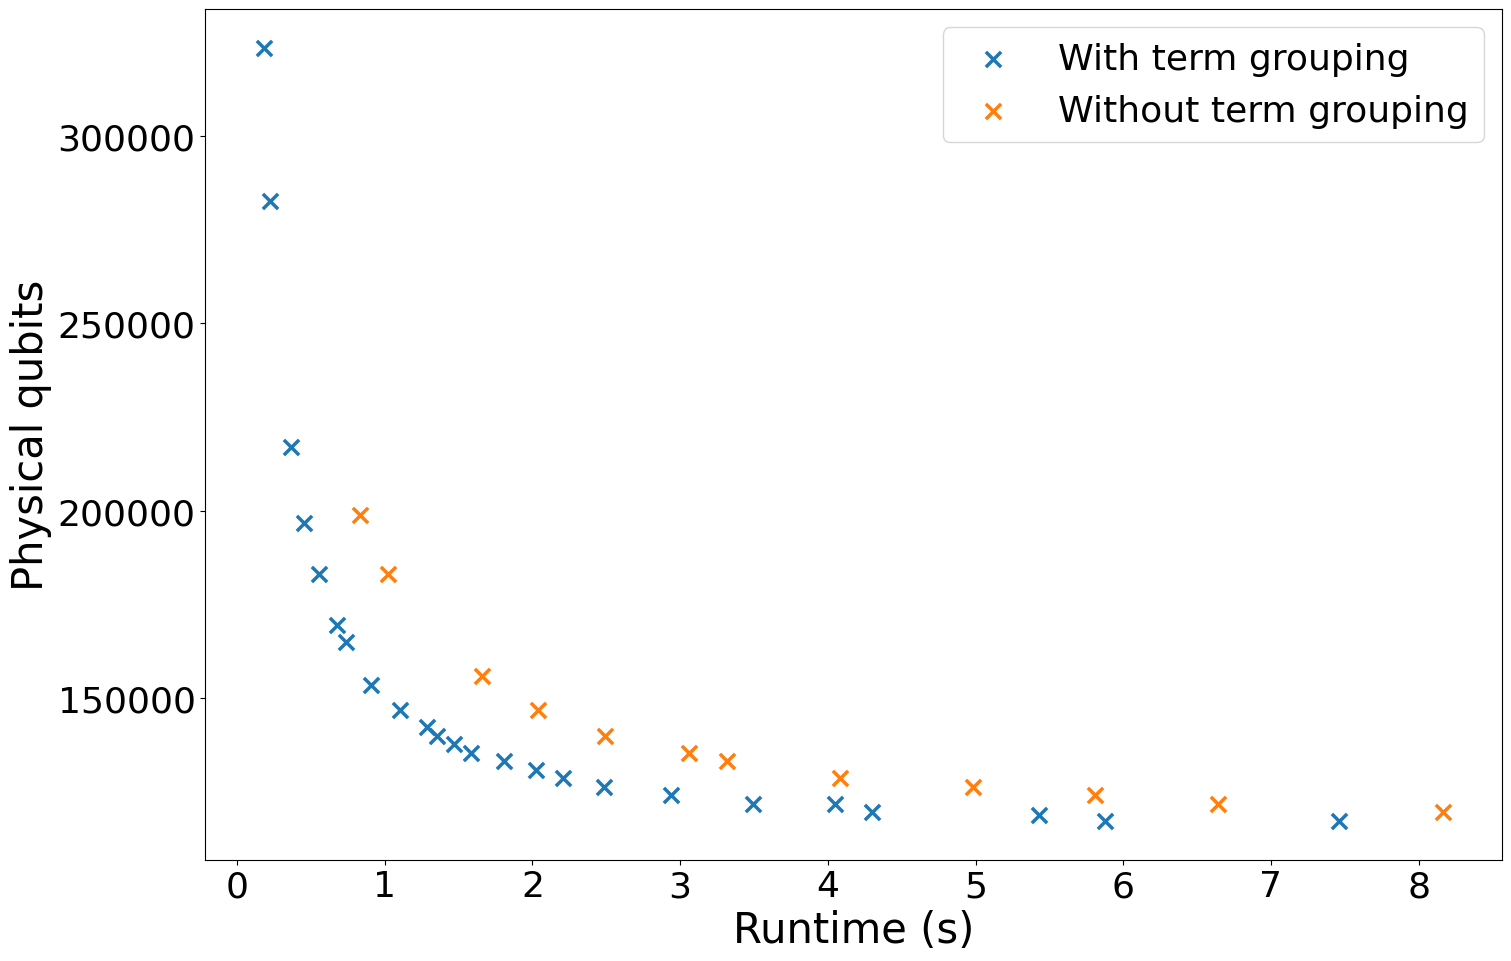

In [7]:
fig = plot_estimates([results, results_ungrouped], runtime_unit="s", figsize=(15, 9.5),
                     scatter_args={"marker": "x", "s": 120, "linewidths": 2.5})
ax = fig.axes[0]
ax.set_xscale("linear")
ax.set_yscale("linear")
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.set_ylabel(ax.get_ylabel(), fontsize=30)
ax.tick_params(axis="both", labelsize=26)
ax.legend(fontsize=26, loc="upper right")
fig.set_layout_engine("constrained")
fig